Summary statistics for total:
 count    4.250000e+02
mean     1.317572e+05
std      1.409593e+05
min      1.555750e+03
25%      5.690200e+04
50%      9.358250e+04
75%      1.772236e+05
max      1.056878e+06
Name: total, dtype: float64

Age group shares:
 18_30    0.044985
31_40    0.070185
41_50    0.093365
51_60    0.170681
60_      0.620784
dtype: float64


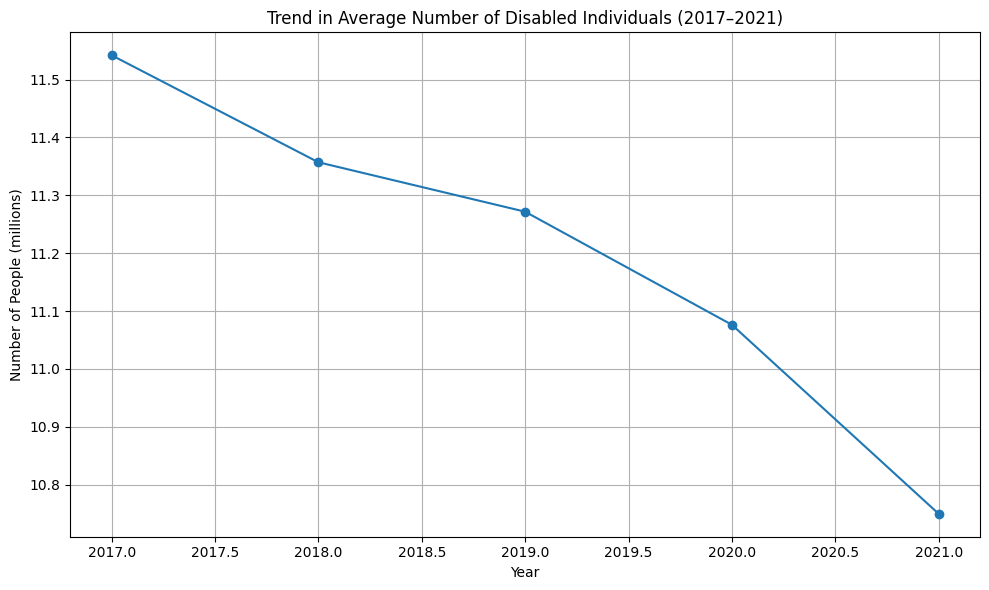

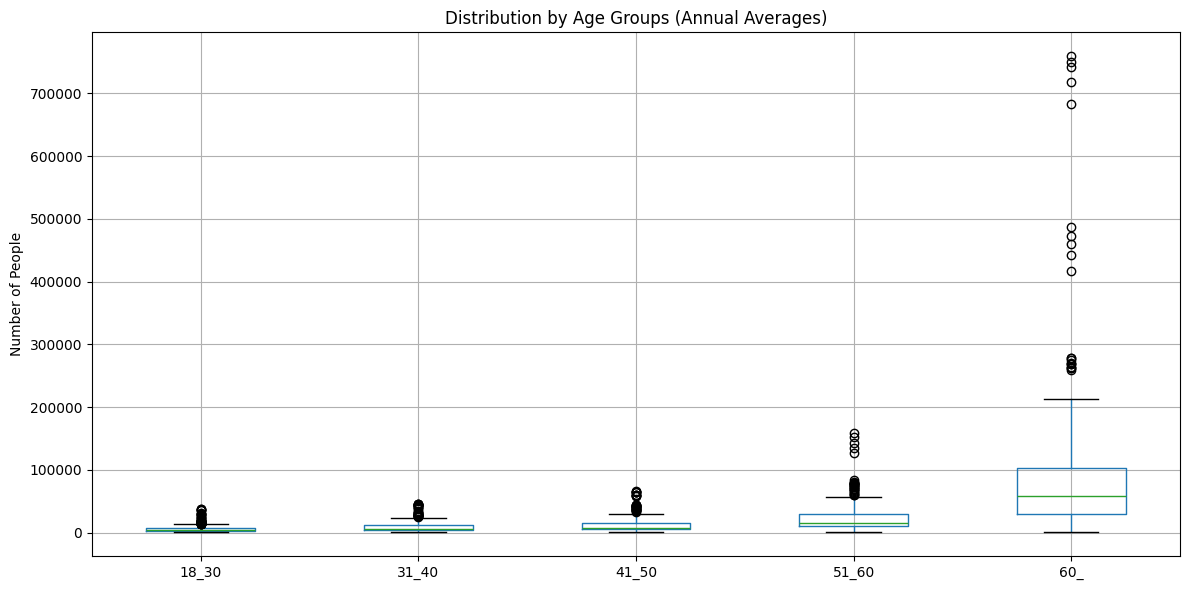

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/disabled_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Convert date and extract year/month
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# 4. Exclude incomplete year (2022)
df = df[df["year"] < 2022]

# 5. Aggregate by region and year (use MEAN, not sum)
grouped = df.groupby(["region_standard", "year"]).agg({
    "total": "mean",
    "18_30": "mean",
    "31_40": "mean",
    "41_50": "mean",
    "51_60": "mean",
    "60_": "mean"
}).reset_index()

# 6. Summary statistics
print("Summary statistics for total:\n", grouped["total"].describe())

# 7. Age group shares
age_cols = ["18_30", "31_40", "41_50", "51_60", "60_"]
age_shares = grouped[age_cols].sum() / grouped["total"].sum()
print("\nAge group shares:\n", age_shares)

# 8. Trend over time
total_by_year = grouped.groupby("year")["total"].sum()

plt.figure(figsize=(10,6))
plt.plot(total_by_year.index, total_by_year.values / 1e6, marker="o")
plt.title("Trend in Average Number of Disabled Individuals (2017–2021)")
plt.xlabel("Year")
plt.ylabel("Number of People (millions)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. Boxplot by age groups
plt.figure(figsize=(12,6))
grouped.boxplot(column=age_cols)
plt.title("Distribution by Age Groups (Annual Averages)")
plt.ylabel("Number of People")
plt.grid(True)
plt.tight_layout()
plt.show()

## Analysis of Disability by Region (2017–2021)

### Summary Statistics (Total Number of Disabled Individuals)
- **Median**: ~93,582  
- **Mean**: ~131,572  
- **Minimum**: ~1,556  
- **Maximum**: ~1,056,878  

The gap between mean and median indicates a right-skewed distribution, driven by a small number of highly populated regions.

Previous overestimation issues (caused by summing monthly data) have been corrected by using annual averages.

---

### Trend Over Time (2017–2021)
- The total number of disabled individuals **decreases** from ~11.56 million to ~10.75 million.  
- Possible explanations include demographic changes, improvements in health conditions, or changes in reporting and classification systems.  

The trend plot clearly shows a gradual downward pattern.

---

### Age Distribution

| Age Group | Share |
|----------|------|
| 18–30    | 4.5% |
| 31–40    | 7.0% |
| 41–50    | 9.3% |
| 51–60    | 17.1% |
| **60+**  | **62.1%** |

- The majority of disabled individuals belong to the **60+ age group**, reflecting strong age-related effects.  
- Younger age groups represent a relatively small share of total disability.

---

### Interpretation
- Disability is strongly associated with aging, making age structure a key driver of regional differences.  
- Regions with older populations are likely to have higher disability levels, even if other socio-economic indicators are similar.  
- The observed skewness is largely explained by population size and demographic composition rather than random variation.  

The boxplot confirms the presence of higher variability in older age groups, especially in densely populated regions.

---

### Conclusion
Disability patterns are closely linked to demographic structure, particularly aging.

These indicators provide important context for regional vulnerability and complement other health and socio-economic variables in the clustering stage.

In [2]:
grouped.to_csv("../../data/clean/disabled_AfterEDA.csv", index=False)